In [1]:
import numpy as np
import pandas as pd
import os
import vectorbtpro as vbt
import quantstats as qs

In [ ]:
MIN_STOCKS = 25
TOP_QUANTILE = 0.80
INIT_CASH = 1000000
COST_BPS = 20
FEE_RATE = COST_BPS / 10000
REPORTING_LAG_MONTHS = 4

In [88]:
BANK_TICKERS = {
    "ABB", "ACB", "BAB", "BID", "BVB", "CTG", "EIB", "HDB", "KLB", "LPB",
    "MBB", "MSB", "NAB", "NVB", "OCB", "PGB", "SGB", "SHB", "SSB", "STB",
    "TCB", "TPB", "VAB", "VBB", "VCB", "VIB", "VPB",
}
SECURITIES_TICKERS = {
    "AAS", "AGR", "APG", "APS", "ART", "BMS", "BSI", "BVS", "CSI", "CTS",
    "DSC", "DSE", "EVS", "FTS", "HAC", "HBS", "HCM", "IVS", "MBS", "ORS",
    "PSI", "SBS", "SHS", "SSI", "TCI", "TVB", "TVC", "TVS", "VCI", "VDS",
    "VFS", "VIG", "VIX", "VND", "WSS",
}
INSURANCE_TICKERS = {
    "ABI", "AIC", "BHI", "BIC", "BLI", "BMI", "BSH", "BVH", "MIG", "PGI",
    "PRE", "PTI", "PVI", "VNR",
}
OTHER_FINANCIAL_TICKERS = {"EVF", "IPA"}
FINANCIAL_PREFIX_EXCLUSIONS = ("E1VF", "FUE", "FUC")

FINANCIAL_TICKER_EXCLUSIONS = (
    BANK_TICKERS | SECURITIES_TICKERS | INSURANCE_TICKERS | OTHER_FINANCIAL_TICKERS
)


# data

In [89]:
raw_fund = pd.read_csv(r"D:\quant idea local\quant-idea\ranking\data_ranking\data_fund\fundamental.csv", index_col=0)
raw_fund = raw_fund.rename(columns={'Mã':'ticker'})

In [90]:
numeric_cols = ['MV', 'Quarter', 'Year', 'D.A', 'GEBT', 'ROE', 'EPS',
                'FCFF', 'GGP', 'GRev', 'EV.EBITDA', 'P.E', 'P.B',
                'FCF', 'LNG', 'LNT']
raw_fund[numeric_cols] = raw_fund[numeric_cols].apply(pd.to_numeric, errors = 'coerce')

In [91]:
financial_mask = raw_fund['ticker'].isin(FINANCIAL_TICKER_EXCLUSIONS) | raw_fund['ticker'].str.startswith(FINANCIAL_PREFIX_EXCLUSIONS)
fund = raw_fund[~financial_mask].copy()
fund
fund.columns

Index(['ticker', 'MV', 'Quarter', 'Year', 'D.A', 'GEBT', 'ROE', 'EPS', 'FCFF',
       'GGP', 'GRev', 'EV.EBITDA', 'P.E', 'P.B', 'FCF', 'LNG', 'LNT'],
      dtype='object')

In [92]:
fund = fund.rename(columns={
    "MV": 'mv',
    "Quarter": 'quarter',
    'Year': 'year',
    'D.A': 'd_a',
    'GEBT': 'ebt_growth',
    'ROE': 'roe',
    'EPS': 'eps',
    'FCFF': 'fcff',
    'GGP': 'gross_profit_growth',
    'GRev': 'revenue_growth',
    'EV.EBITDA': 'ev_ebitda',
    'P.E': 'pe',
    'P.B': 'pb',
    'FCF': 'fcf',
    'LNG': 'gross_margin',
    'LNT': 'net_margin'
})

In [93]:
price = []

for ticker in sorted(fund['ticker'].unique()):
    path = f"D:/quant idea local/quant-idea/ranking/data_ranking/data_1d/{ticker}_1d.pkl"
    if os.path.exists(path):
        df = pd.read_pickle(path)
        df = df[['datetime', 'close']].copy()
        df['ticker'] = ticker
        price.append(df[['ticker', 'datetime', 'close']])

prices = pd.concat(price, ignore_index= True)
prices['date'] = pd.to_datetime(prices['datetime'], errors='coerce')
prices['close'] = pd.to_numeric(prices['close'], errors='coerce')
prices = prices.dropna(subset = ['ticker', 'date', 'close']).sort_values(['ticker', 'date']).copy()
prices

,ticker,datetime,close,date
0,AAA,2013-01-02 07:00:00,3.830,2013-01-02 07:00:00
1,AAA,2013-01-03 07:00:00,3.724,2013-01-03 07:00:00
2,AAA,2013-01-04 07:00:00,3.777,2013-01-04 07:00:00
3,AAA,2013-01-07 07:00:00,3.751,2013-01-07 07:00:00
4,AAA,2013-01-08 07:00:00,3.751,2013-01-08 07:00:00
...,...,...,...,...
983865,YEG,2025-12-25 07:00:00,12.850,2025-12-25 07:00:00
983866,YEG,2025-12-26 07:00:00,12.450,2025-12-26 07:00:00
983867,YEG,2025-12-29 07:00:00,12.400,2025-12-29 07:00:00
983868,YEG,2025-12-30 07:00:00,12.450,2025-12-30 07:00:00


In [94]:
# Build accounting variables used by the signal
eps_lag = fund.groupby('ticker')['eps'].shift(4)
fund['eps_growth'] = 2 * (fund['eps'] - eps_lag) / (fund['eps'].abs() + eps_lag.abs()).replace(0, np.nan)

fund['earnings_yield'] = np.where(fund['pe'] > 0, 1 / fund['pe'], np.nan)
fund['book_to_price'] = np.where(fund['pb'] > 0, 1 / fund['pb'], np.nan)
fund['ebitda_to_ev'] = np.where(fund['ev_ebitda'] > 0, 1 / fund['ev_ebitda'], np.nan)

positive_mv = fund['mv'].where(fund['mv'] > 0)
fund['fcf_yield'] = fund['fcf'] / positive_mv


In [95]:
prices['month'] = prices['date'].dt.to_period('M').dt.to_timestamp('M')
monthly = (
    prices.sort_values(['ticker', 'date'])
    .groupby(['ticker', 'month'])
    .tail(1)[['ticker', 'month', 'close']]
)

all_months = pd.date_range(monthly['month'].min(), monthly['month'].max(), freq='ME')
tickers = monthly['ticker'].drop_duplicates().sort_values()
full_index  = pd.MultiIndex.from_product([tickers, all_months], names = ['ticker', 'month'])

monthly = (
    monthly.set_index(['ticker', 'month'])
    .reindex(full_index)
    .reset_index()
    .sort_values(['ticker', 'month'])
)

monthly['close'] = monthly.groupby('ticker')['close'].ffill()

monthly

,ticker,month,close
0,AAA,2013-01-31,3.777
1,AAA,2013-02-28,3.804
2,AAA,2013-03-31,3.540
3,AAA,2013-04-30,3.592
4,AAA,2013-05-31,4.121
...,...,...,...
55999,YEG,2025-08-31,14.100
56000,YEG,2025-09-30,14.250
56001,YEG,2025-10-31,12.500
56002,YEG,2025-11-30,12.000


In [96]:
price_matrix = monthly.pivot(index='month', columns='ticker', values='close').sort_index()
price_matrix


ticker,AAA,AAM,AAT,ABR,ABS,ABT,ACC,ACG,ACL,ADG,...,VRE,VSC,VSH,VSI,VTB,VTO,VTP,VVS,YBM,YEG
month,,,,,,,,,,,,,,,,,,,,,
2013-01-31,3.777,9.658,NaN,NaN,NaN,14.202,4.133,NaN,3.610,NaN,...,NaN,2.451,6.143,2.094,2.850,1.710,NaN,NaN,NaN,NaN
2013-02-28,3.804,9.697,NaN,NaN,NaN,14.639,4.073,NaN,3.610,NaN,...,NaN,2.617,5.785,2.183,2.680,1.885,NaN,NaN,NaN,NaN
2013-03-31,3.540,9.538,NaN,NaN,NaN,15.258,4.583,NaN,3.657,NaN,...,NaN,2.949,6.041,2.453,2.816,1.745,NaN,NaN,NaN,NaN
2013-04-30,3.592,9.538,NaN,NaN,NaN,14.566,4.359,NaN,3.561,NaN,...,NaN,2.677,6.348,2.243,2.782,1.536,NaN,NaN,NaN,NaN
2013-05-31,4.121,9.142,NaN,NaN,NaN,14.894,5.215,NaN,3.530,NaN,...,NaN,2.865,7.730,1.824,3.563,1.723,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,8.120,7.170,3.58,13.37,3.77,64.000,13.950,35.501,11.686,9.40,...,30.40,30.000,45.770,20.400,9.082,12.150,97.891,34.6,10.847,14.10
2025-09-30,8.200,7.100,3.79,14.95,3.63,68.800,13.750,34.536,12.740,9.45,...,32.10,29.500,45.868,19.632,9.082,11.800,97.100,40.5,10.619,14.25
2025-10-31,8.150,7.000,3.52,12.80,3.00,71.300,13.350,35.115,12.788,9.10,...,33.30,23.200,44.010,19.200,12.900,12.200,115.500,61.2,10.581,12.50


In [97]:
# gia dinh bao cao tai chinh co the dung sau 4 thang
panel = fund.copy()
quarter_end_month = fund['quarter'].map({1: 3, 2: 6, 3: 9, 4: 12})
panel['period_end'] = pd.to_datetime(
    {'year': fund['year'], 'month': quarter_end_month, 'day': 1},
    errors='coerce'
) + pd.offsets.MonthEnd(0)
panel['signal_date'] = (
    panel['period_end'] + pd.DateOffset(months=REPORTING_LAG_MONTHS)
).dt.to_period('M').dt.to_timestamp('M')

panel = (
    panel.sort_values(['ticker', 'signal_date', 'period_end'])
    .drop_duplicates(['ticker', 'signal_date'], keep='last')
)

panel = panel.merge(
    monthly,
    left_on=['ticker', 'signal_date'],
    right_on=['ticker', 'month'],
    how='left'
).drop(columns='month')

panel

,ticker,mv,quarter,year,d_a,ebt_growth,roe,eps,fcff,gross_profit_growth,...,gross_margin,net_margin,eps_growth,earnings_yield,book_to_price,ebitda_to_ev,fcf_yield,period_end,signal_date,close
0,AAA,NaN,1,2008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-03-31,2008-07-31,NaN
1,AAA,NaN,2,2008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-06-30,2008-10-31,NaN
2,AAA,NaN,3,2008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-09-30,2009-01-31,NaN
3,AAA,NaN,4,2008,0.58,NaN,0.2564,NaN,-1.026268e+11,NaN,...,0.2093,0.0921,NaN,NaN,NaN,NaN,NaN,2008-12-31,2009-04-30,NaN
4,AAA,NaN,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-03-31,2009-07-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,YEG,2.186543e+12,4,2024,0.23,1.7211,0.0893,639.45,-1.642559e+11,-0.2826,...,0.1665,0.1195,0.818202,0.056085,0.657895,0.017806,-0.075121,2024-12-31,2025-04-30,11.8
25916,YEG,2.493426e+12,1,2025,0.10,1.0123,0.0865,877.16,-2.808651e+11,1.9238,...,0.1703,0.1143,0.761795,0.067476,0.806452,0.028011,-0.112642,2025-03-31,2025-07-31,13.0
25917,YEG,2.407116e+12,2,2025,0.08,1.7671,0.0886,992.27,-2.268324e+11,2.0196,...,0.1645,0.1131,0.844974,0.079051,0.847458,0.048544,-0.094234,2025-06-30,2025-10-31,12.5
25918,YEG,2.349575e+12,3,2025,0.09,-0.6575,0.0715,806.13,-2.492897e+11,-0.4278,...,0.1362,0.0911,0.425509,0.065789,0.877193,0.042337,-0.106100,2025-09-30,2026-01-31,NaN


In [98]:
component_groups = {
    'value_score': ['earnings_yield', 'book_to_price', 'ebitda_to_ev'],
    'quality_score': ['roe', 'gross_margin', 'net_margin'],
    'growth_score': ['gross_profit_growth', 'revenue_growth', 'ebt_growth', 'eps_growth'],
    'cash_score': ['fcf_yield']
}

minimum_components = {
    'value_score': 2,
    'quality_score': 1,
    'growth_score': 2,
    'cash_score': 1
}


In [99]:
for score_name, columns in component_groups.items():
    rank_columns = []

    for column in columns:
        clean_column = f'{column}_clean'
        rank_column = f'{column}_rank'

        panel[clean_column] = panel.groupby('signal_date')[column].transform(
            lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))
        )
        panel[rank_column] = panel.groupby('signal_date')[clean_column].rank(pct=True)
        rank_columns.append(rank_column)

    valid_components = panel[rank_columns].notna().sum(axis=1)
    panel[score_name] = panel[rank_columns].mean(axis=1)
    panel.loc[valid_components < minimum_components[score_name], score_name] = np.nan


In [100]:
panel['d_a_clean'] = panel.groupby('signal_date')['d_a'].transform(
    lambda s: s.clip(s.quantile(0.01), s.quantile(0.99))
)
panel['balance_score'] = panel.groupby('signal_date')['d_a_clean'].rank(ascending=False, pct=True)

support_components = ['quality_score', 'growth_score', 'cash_score', 'balance_score']
panel['support_component_count'] = panel[support_components].notna().sum(axis=1)
panel['support_score'] = panel[support_components].mean(axis=1)
panel.loc[panel['support_component_count'] < 2, 'support_score'] = np.nan
panel['conditioned_value_score'] = panel['value_score'] * panel['support_score']

In [101]:
panel[['ticker', 'signal_date', 'value_score', 'support_score', 'conditioned_value_score']].dropna().tail()

,ticker,signal_date,value_score,support_score,conditioned_value_score
25914,YEG,2025-01-31,0.141830,0.532760,0.075561
25915,YEG,2025-04-30,0.239412,0.492719,0.117963
25916,YEG,2025-07-31,0.356729,0.587577,0.209606
25917,YEG,2025-10-31,0.431888,0.599119,0.258752
25918,YEG,2026-01-31,0.380066,0.445381,0.169274


In [ ]:
strategy_signals = ['value_score', 'conditioned_value_score']
weight_dict = {}

for signal in strategy_signals:
    weight = pd.DataFrame(np.nan, index=price_matrix.index, columns=price_matrix.columns)
    signal_panel = panel.dropna(subset=[signal, 'close']).copy()

    for dt, data in signal_panel.groupby('signal_date'):
        if dt not in weight.index:
            continue

        tradable = price_matrix.columns[price_matrix.loc[dt].notna()]
        data = data[data['ticker'].isin(tradable)].copy()
        if len(data) < MIN_STOCKS:
            continue

        weight.loc[dt, tradable] = 0.0
        data['rank_pct'] = data[signal].rank(pct=True)
        top = data[data['rank_pct'] >= TOP_QUANTILE].copy()
        if len(top) == 0:
            continue

        weight.loc[dt, top['ticker']] = 1.0 / len(top)

    weight_dict[signal] = weight


In [103]:
first_rebalance = {
    signal: weight.index[weight.notna().any(axis=1)].min()
    for signal, weight in weight_dict.items()
}

common_start = max(first_rebalance.values())
common_end = price_matrix.index.max()

first_rebalance, common_start, common_end


({'value_score': Timestamp('2013-01-31 00:00:00'),
  'conditioned_value_score': Timestamp('2013-01-31 00:00:00')},
 Timestamp('2013-01-31 00:00:00'),
 Timestamp('2025-12-31 00:00:00'))

Start Index                           2013-01-31 00:00:00
End Index                             2025-12-31 00:00:00
Total Duration                         4748 days 03:39:36
Start Value                                     1000000.0
Min Value                                   998003.992016
Max Value                                 12563527.267127
End Value                                 12296219.505135
Total Return [%]                              1129.621951
Benchmark Return [%]                           464.839209
Position Coverage [%]                               100.0
Max Gross Exposure [%]                              100.0
Max Drawdown [%]                                41.105266
Max Drawdown Duration                  1065 days 06:58:30
Total Orders                                         3600
Total Fees Paid                             329681.069994
Total Trades                                         1688
Win Rate [%]                                    71.842267
Best Trade [%]

c:\Users\haiye\anaconda3\envs\py310\lib\site-packages\vectorbtpro-2024.11.12-py3.10.egg\vectorbtpro\generic\plots_builder.py:394: UserWarning:

Subplot 'orders' does not support grouped data

c:\Users\haiye\anaconda3\envs\py310\lib\site-packages\vectorbtpro-2024.11.12-py3.10.egg\vectorbtpro\generic\plots_builder.py:394: UserWarning:

Subplot 'trade_pnl' does not support grouped data



                           Strategy
-------------------------  ----------
Start Period               2013-01-31
End Period                 2025-12-31
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          1,129.62%
CAGR﹪                     5659.71%

Sharpe                     5.24
Prob. Sharpe Ratio         100.0%
Smart Sharpe               4.54
Sortino                    9.74
Smart Sortino              8.43
Sortino/√2                 6.88
Smart Sortino/√2           5.96
Omega                      2.56

Max Drawdown               -41.11%
Max DD Date                2022-12-31
Max DD Period Start        2022-04-30
Max DD Period End          2025-01-31
Longest DD Days            1008
Volatility (ann.)          84.69%
Calmar                     137.69
Skew                       0.03
Kurtosis                   2.13

Expected Daily %           1.62%
Expected Monthly %         1.62%
Expected Yearly %          21.29%
Kelly Criterion            38.63%
Ris

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-04-30,2022-12-31,2025-01-31,1008,-41.105266,-39.913739
2,2019-05-31,2020-03-31,2020-07-31,428,-27.580676,-14.064571
3,2014-04-30,2014-05-31,2014-07-31,93,-8.568193,-6.051246
4,2021-12-31,2022-01-31,2022-01-31,32,-8.305244,-1.555609
5,2025-03-31,2025-04-30,2025-06-30,92,-7.637175,-3.572456


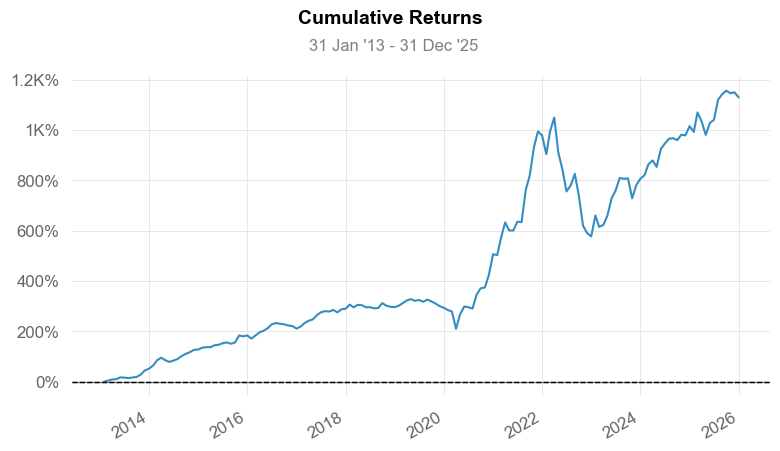

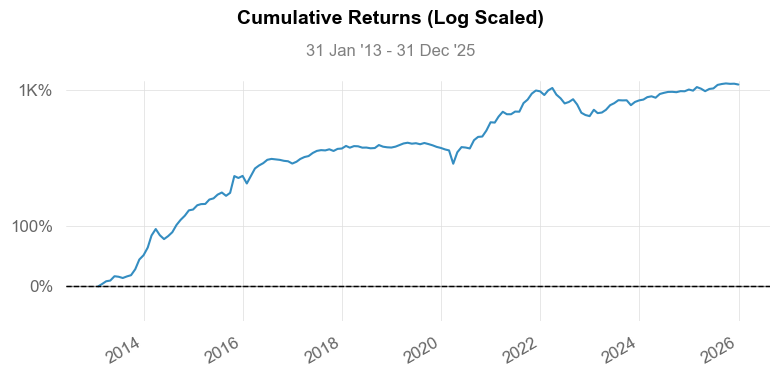

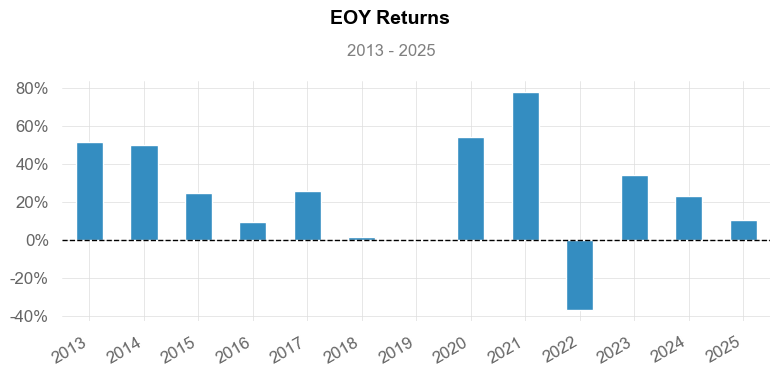

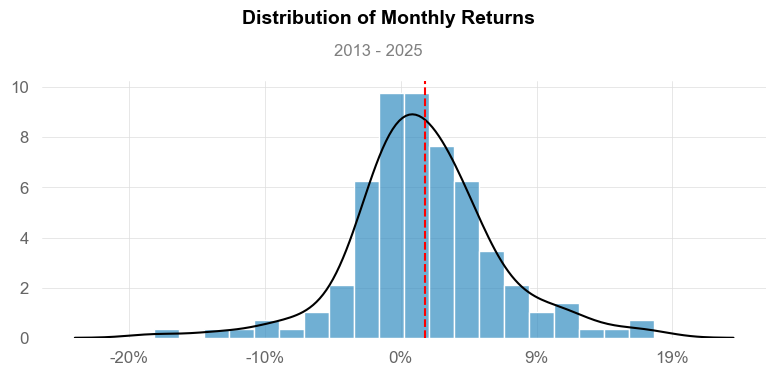

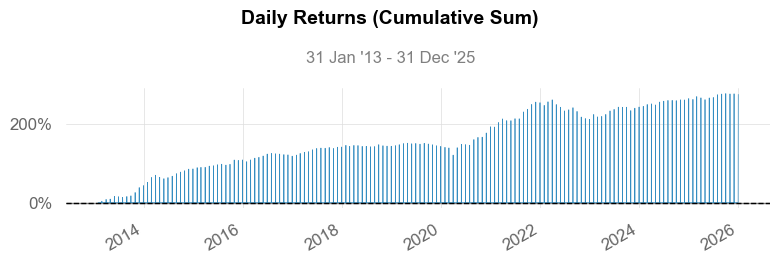

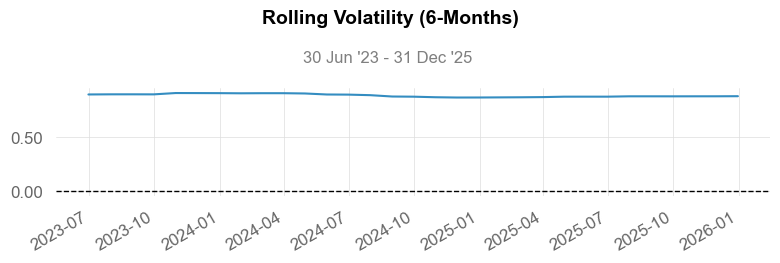

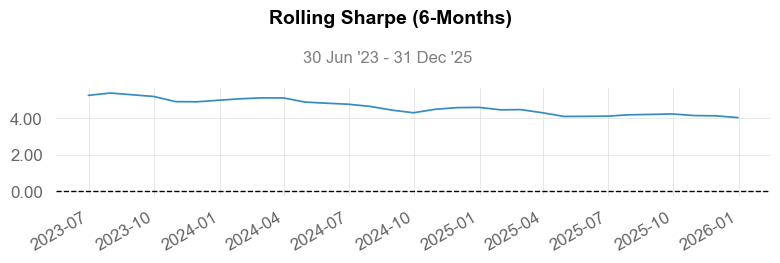

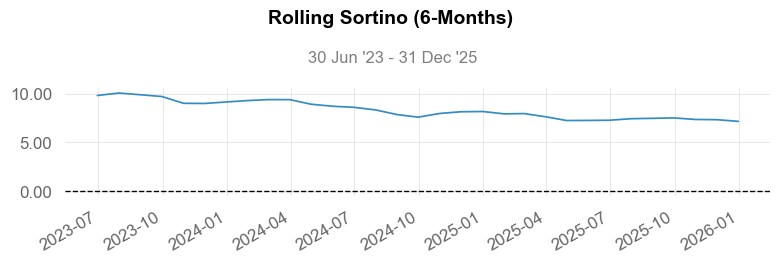

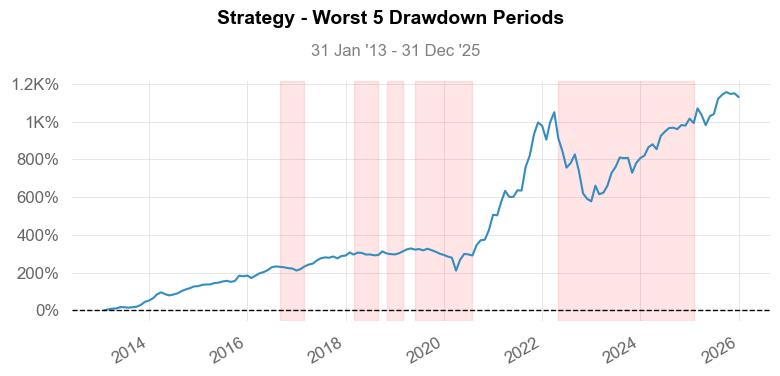

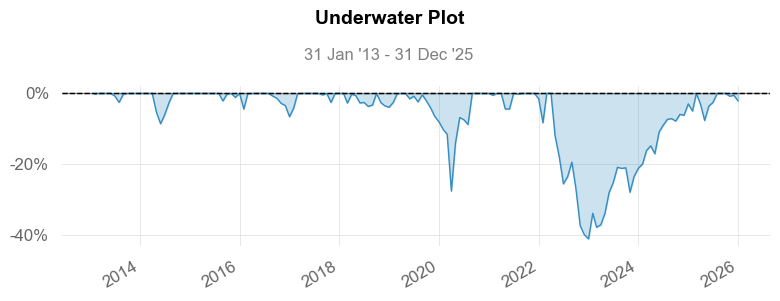

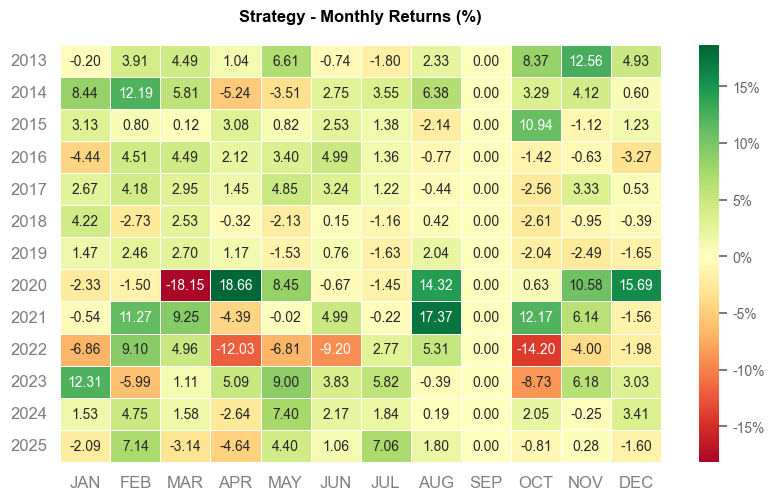

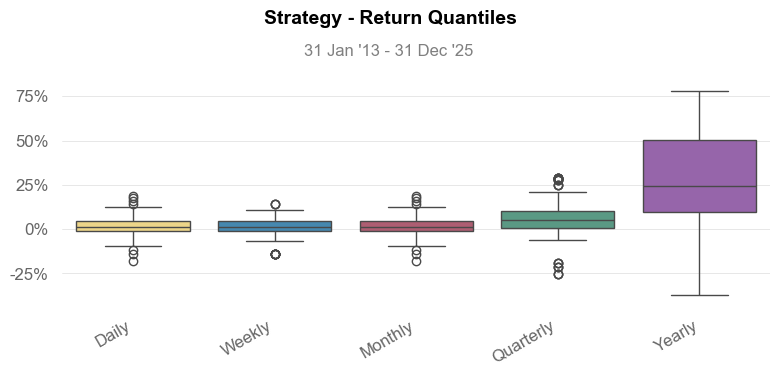

Start Index                           2013-01-31 00:00:00
End Index                             2025-12-31 00:00:00
Total Duration                         4748 days 03:39:36
Start Value                                     1000000.0
Min Value                                   998003.992016
Max Value                                 16441509.786233
End Value                                 16146378.117283
Total Return [%]                              1514.637812
Benchmark Return [%]                           464.839209
Position Coverage [%]                               100.0
Max Gross Exposure [%]                              100.0
Max Drawdown [%]                                35.312745
Max Drawdown Duration                   821 days 19:05:42
Total Orders                                         3813
Total Fees Paid                             483319.456149
Total Trades                                         1850
Win Rate [%]                                    73.415592
Best Trade [%]

c:\Users\haiye\anaconda3\envs\py310\lib\site-packages\vectorbtpro-2024.11.12-py3.10.egg\vectorbtpro\generic\plots_builder.py:394: UserWarning:

Subplot 'orders' does not support grouped data

c:\Users\haiye\anaconda3\envs\py310\lib\site-packages\vectorbtpro-2024.11.12-py3.10.egg\vectorbtpro\generic\plots_builder.py:394: UserWarning:

Subplot 'trade_pnl' does not support grouped data



                           Strategy
-------------------------  ----------
Start Period               2013-01-31
End Period                 2025-12-31
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          1,514.64%
CAGR﹪                     8843.47%

Sharpe                     6.19
Prob. Sharpe Ratio         100.0%
Smart Sharpe               5.48
Sortino                    11.81
Smart Sortino              10.46
Sortino/√2                 8.35
Smart Sortino/√2           7.39
Omega                      2.93

Max Drawdown               -35.31%
Max DD Date                2022-12-31
Max DD Period Start        2022-04-30
Max DD Period End          2024-05-31
Longest DD Days            763
Volatility (ann.)          78.13%
Calmar                     250.43
Skew                       -0.07
Kurtosis                   1.84

Expected Daily %           1.8%
Expected Monthly %         1.8%
Expected Yearly %          23.86%
Kelly Criterion            44.3%
Risk

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-04-30,2022-12-31,2024-05-31,763,-35.312745,-34.264147
2,2019-09-30,2020-03-31,2020-07-31,306,-24.241385,-11.646798
3,2021-12-31,2022-01-31,2022-02-28,60,-9.413759,-1.733898
4,2025-03-31,2025-04-30,2025-06-30,92,-8.696307,-4.676319
5,2014-04-30,2014-05-31,2014-06-30,62,-5.367289,-3.703425


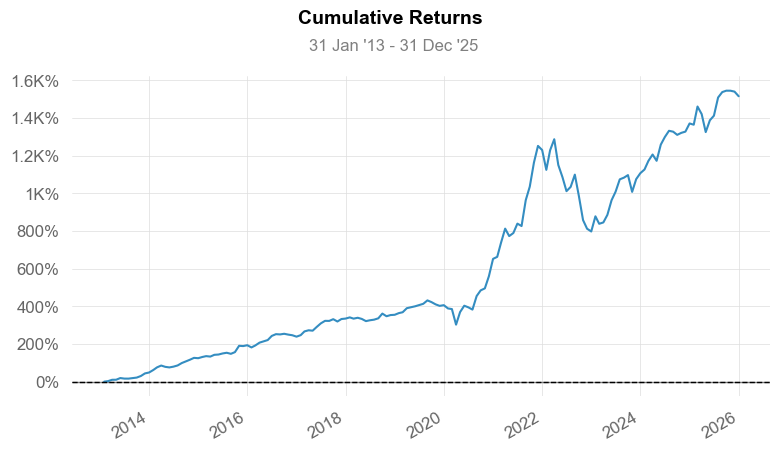

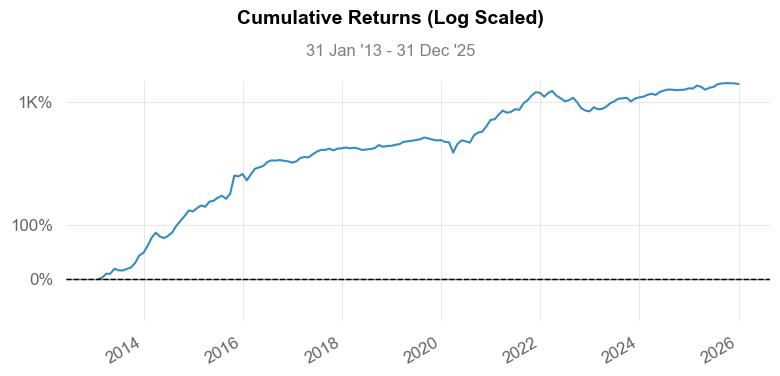

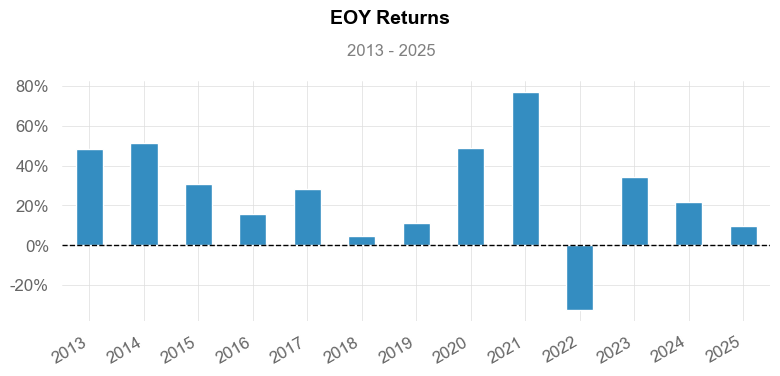

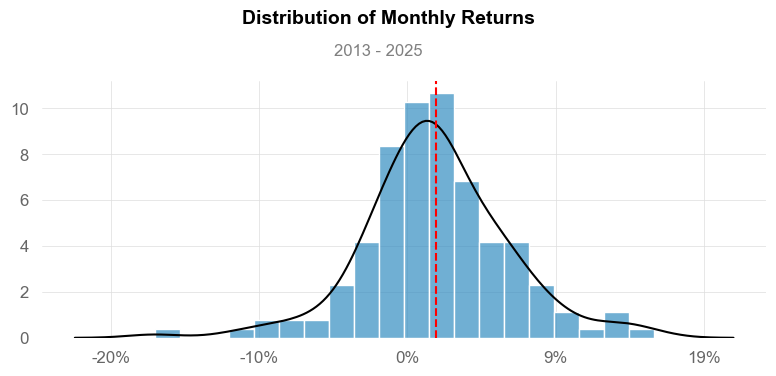

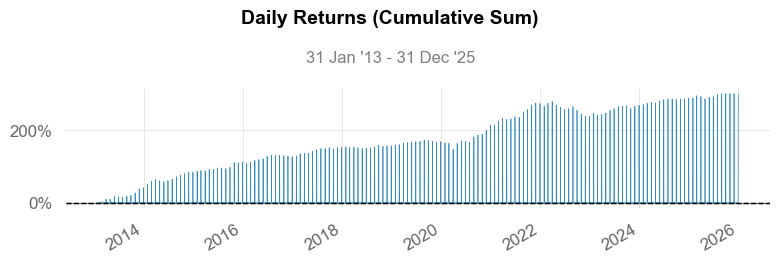

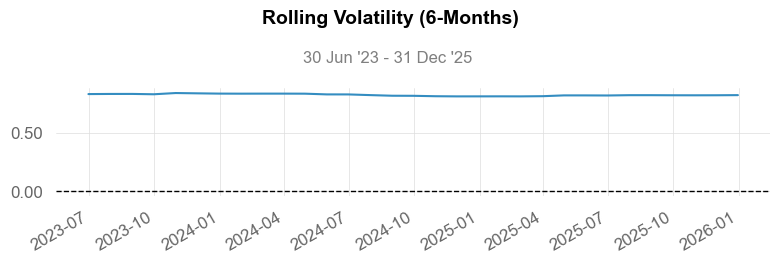

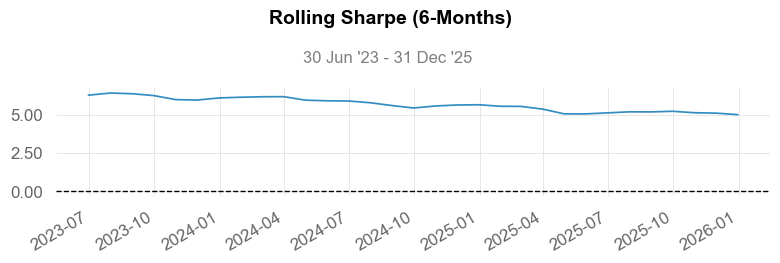

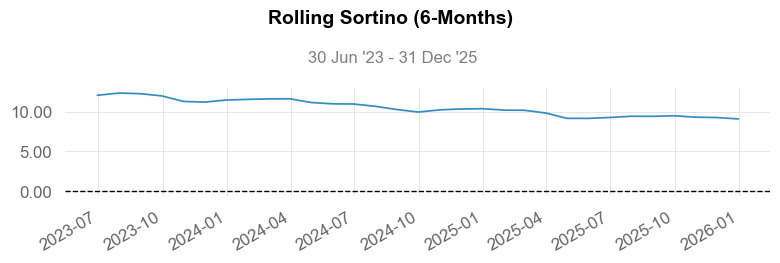

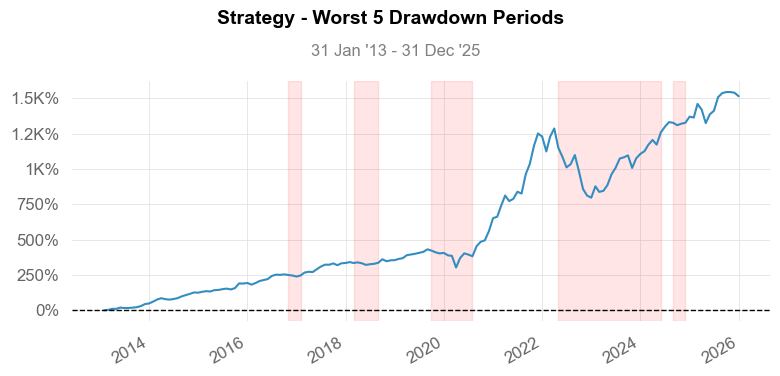

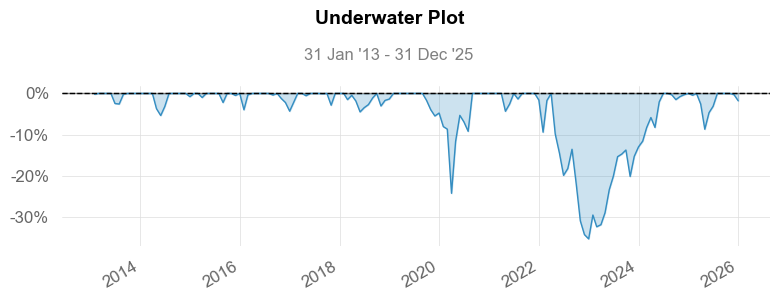

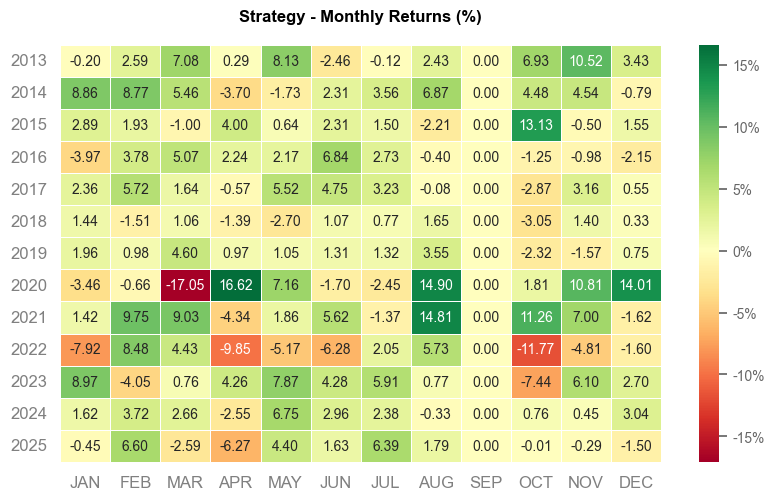

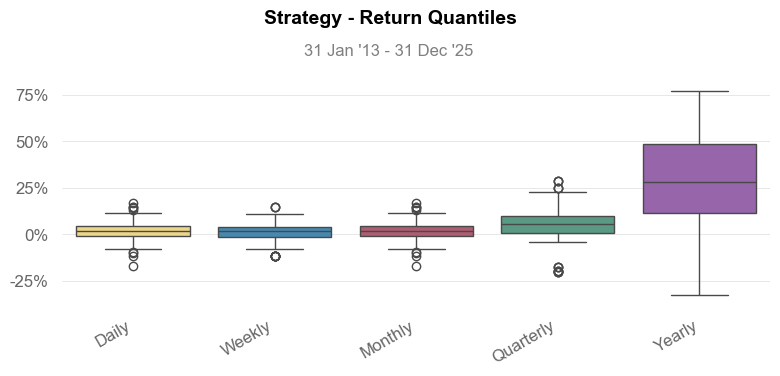

In [ ]:
for signal, weight in weight_dict.items():
    close = price_matrix.loc[common_start:common_end].copy()
    target_weight = weight.reindex(close.index).copy()

    used_cols = target_weight.notna().any(axis=0)
    close = close.loc[:, used_cols]
    target_weight = target_weight.loc[:, used_cols]

    pf = vbt.Portfolio.from_orders(
        close,
        size=target_weight,
        size_type='targetpercent',
        fees=FEE_RATE,
        init_cash=INIT_CASH,
        cash_sharing=True,
        group_by=True
    )

    print(pf.stats())
    pf.plot()

    returns = pf.returns
    qs.reports.full(returns)
